In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_excel('/content/US Superstore data.xls')
df.head()
df = df.drop_duplicates()
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
#Etats avec le plus de ventes
states_sales = (
    df.groupby('State')['Sales']
    .sum()
    .sort_values(ascending=False)
    )
states_sales.head(10)

,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140
Florida,89473.7080
Illinois,80166.1010
Ohio,78258.1360
Michigan,76269.6140


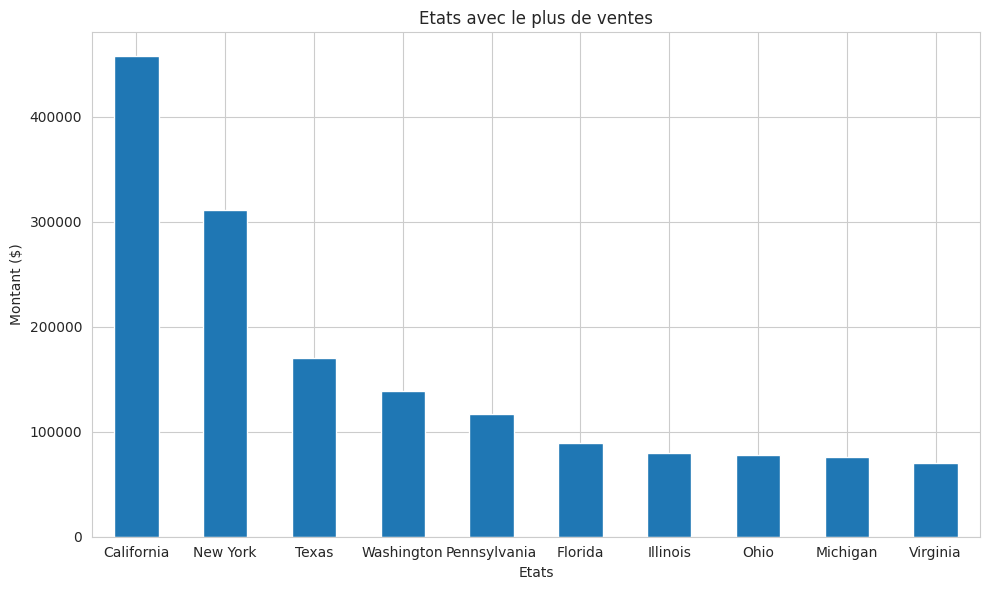

In [15]:
#Visualisation de states_sales
states_sales.head(10).plot(kind='bar', figsize=(10, 6))
plt.title('Etats avec le plus de ventes')
plt.ylabel('Montant ($)')
plt.xlabel('Etats')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
#Comparaison des ventes et bénéfices de New York vs Californie
newyork_californie = df[df['State'].isin(['New York', 'California'])]
comparaison = newyork_californie.groupby('State')[['Sales', 'Profit']].sum()
comparaison

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486


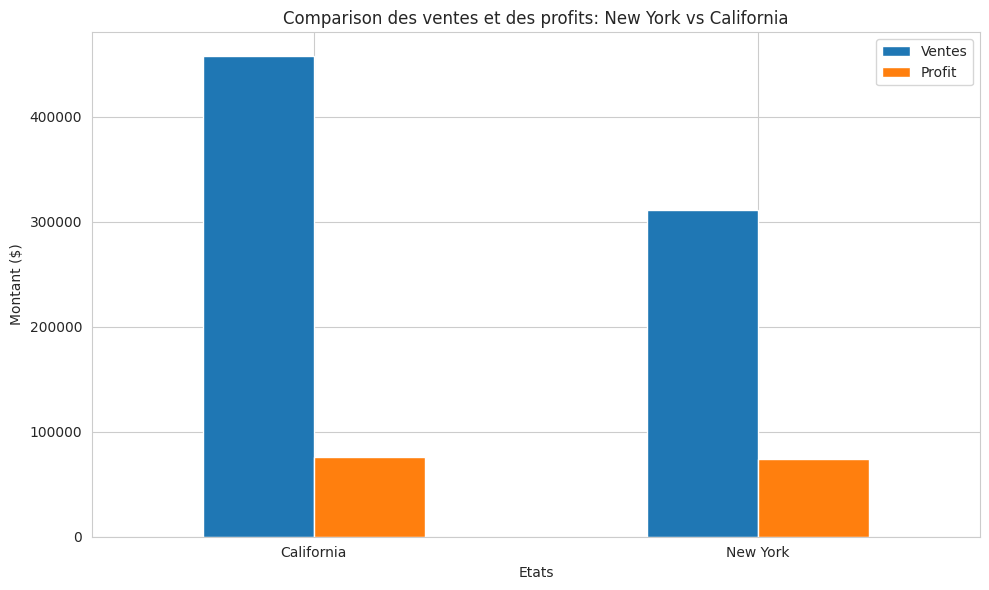

In [14]:
#Visualisation de la comparaison
comparaison.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison des ventes et des profits: New York vs Californie')
plt.ylabel('Montant ($)')
plt.xlabel('Etats')
plt.xticks(rotation=0) # Keep state names horizontal
plt.legend(['Ventes', 'Profit'])
plt.tight_layout()
plt.show()

In [21]:
#Client exceptionnel et son montant à New York
client_max_ny = df[df['State'] == 'New York'].groupby('Customer Name')['Sales'].sum().idxmax()
montant_max_ny = df[(df['State'] == 'New York') & (df['Customer Name'] == client_max_ny)]['Sales'].sum()

f"Le client exceptionnel de New York est : {client_max_ny} et il a dépensé ${montant_max_ny}."

'Le client exceptionnel de New York est : Tom Ashbrook et il a dépensé $13723.498000000001.'

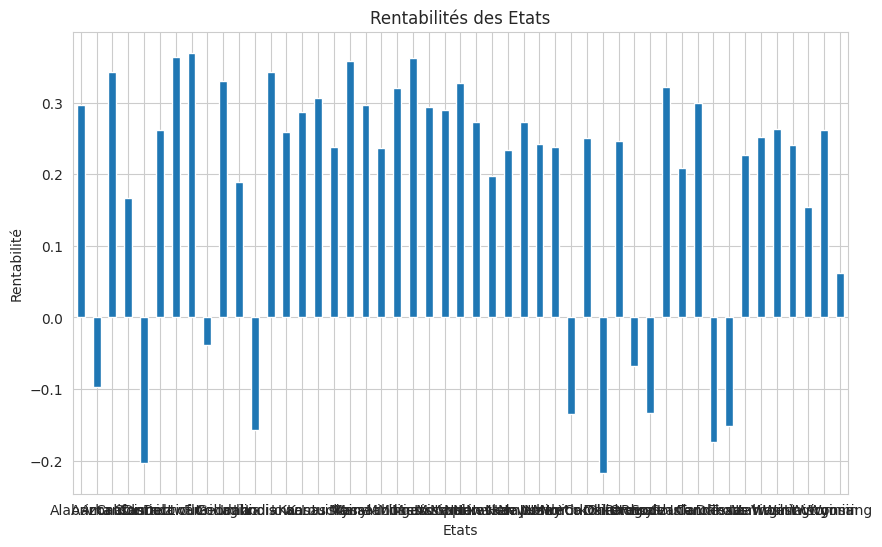

In [23]:
#Différences de rentabilité entre les Etats
rentabilite_par_etat = df.groupby('State')['Profit'].sum() / df.groupby('State')['Sales'].sum()

#visualisation
rentabilite_par_etat.plot(kind='bar', figsize=(10,6))
plt.title('Rentabilités des Etats')
plt.xlabel('Etats')
plt.ylabel('Rentabilité')
plt.xticks(rotation=0)
plt.show()

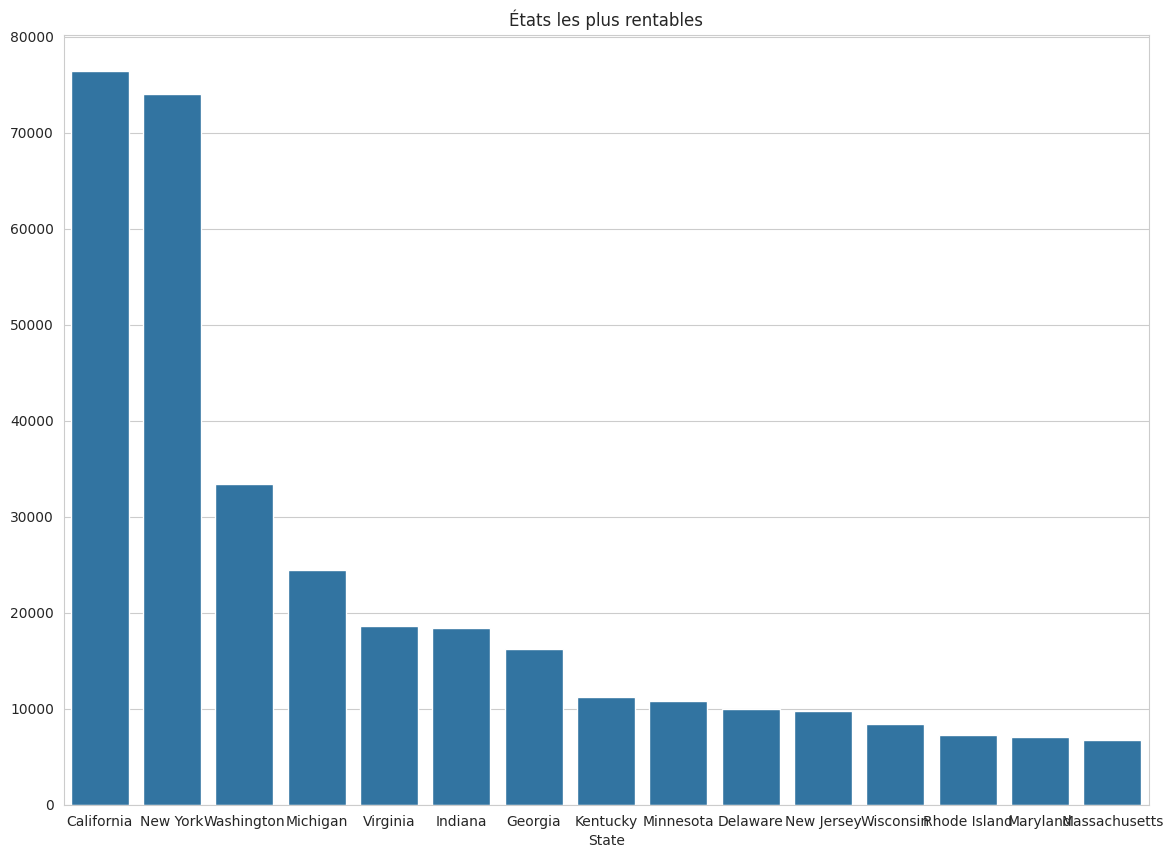

In [26]:
state_profit = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

#Etats les plus rentables
plt.figure(figsize=(14,10))

sns.barplot(
    x=state_profit.head(15).index,
    y=state_profit.head(15).values
)

plt.title("États les plus rentables")
plt.show()

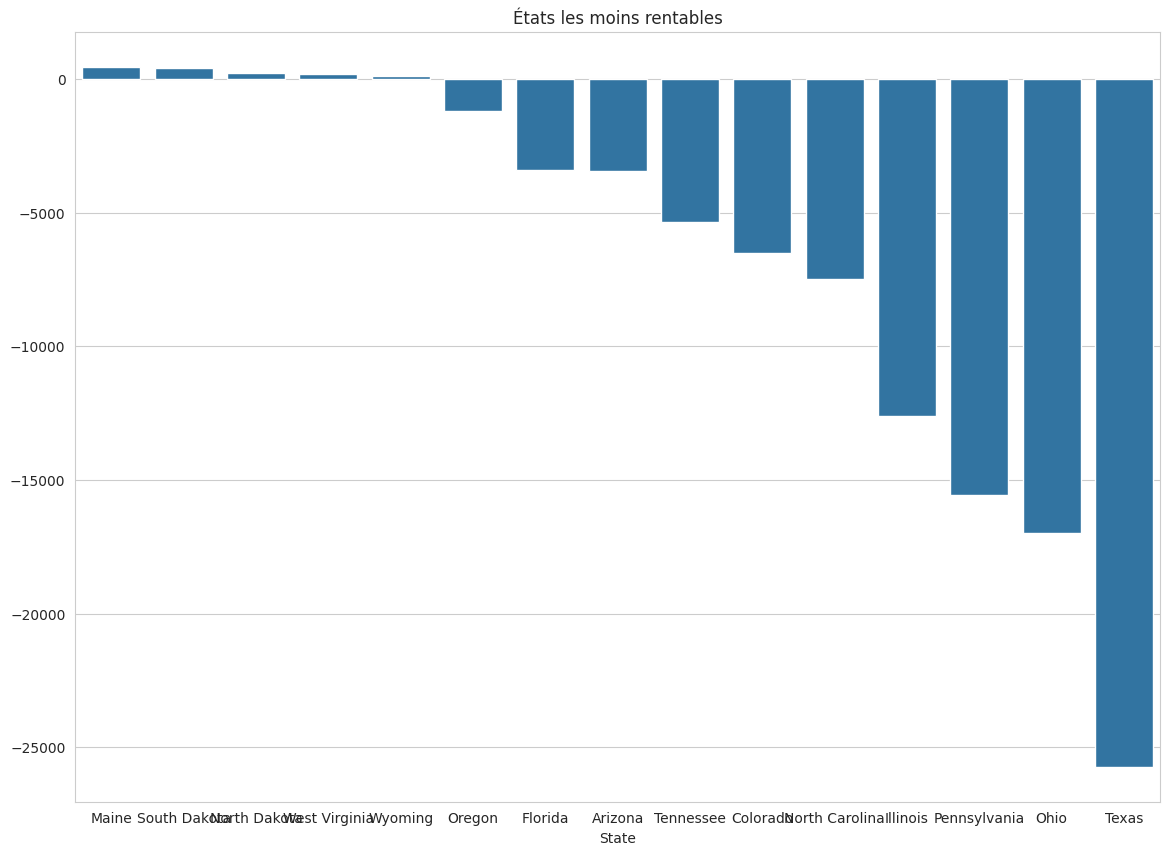

In [27]:
#Etats les moins rentables
plt.figure(figsize=(14,10))

sns.barplot(
    x=state_profit.tail(15).index,
    y=state_profit.tail(15).values
)

plt.title("États les moins rentables")
plt.show()

In [28]:
#Principe de Pareto : est-ce que 20% des clients contribuent à 80% des profits
  #Profit par client
customer_profit = (
    df.groupby('Customer Name')['Profit']
    .sum()
    .sort_values(ascending=False)
)
customer_profit.head(10)

,Profit
Customer Name,
Tamara Chand,8981.3239
Raymond Buch,6976.0959
Sanjit Chand,5757.4119
Hunter Lopez,5622.4292
Adrian Barton,5444.8055
Tom Ashbrook,4703.7883
Christopher Martinez,3899.8904
Keith Dawkins,3038.6254
Andy Reiter,2884.6208


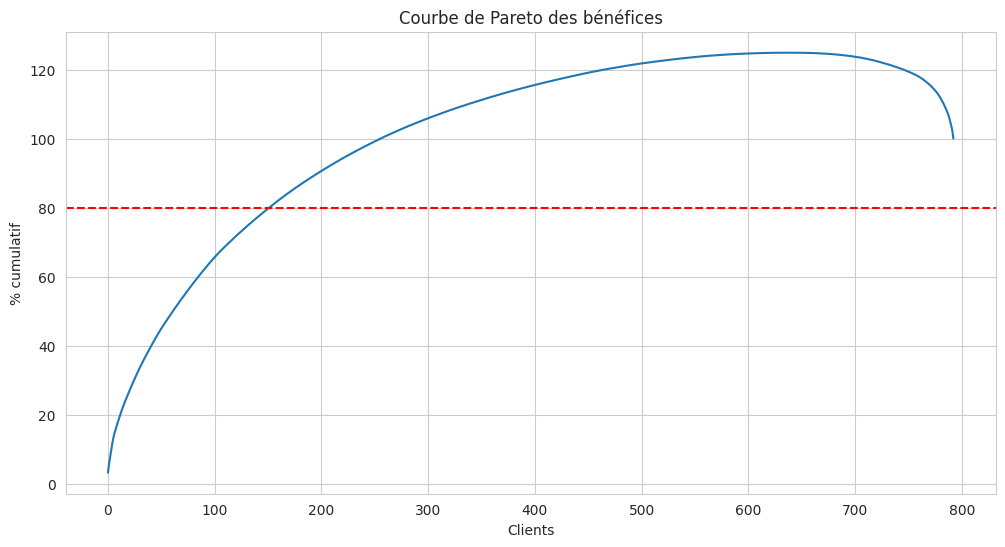

In [29]:
#pourcentage cumulé par client
pareto_profit = customer_profit.reset_index()

pareto_profit["Cum_Profit"] = pareto_profit["Profit"].cumsum()

pareto_profit["Cum_Percent"] = (
    pareto_profit["Cum_Profit"]
    / pareto_profit["Profit"].sum()
) * 100

#Visualisation
plt.figure(figsize=(12,6))

plt.plot(
    range(len(pareto_profit)),
    pareto_profit["Cum_Percent"]
)

plt.axhline(
    y=80,
    color="red",
    linestyle="--"
)

plt.title("Courbe de Pareto des bénéfices")
plt.ylabel("% cumulatif")
plt.xlabel("Clients")

plt.show()

In [30]:
#Nombre de clients necéssaires pour atteindre 80%
clients_80 = len(
    pareto_profit[
        pareto_profit["Cum_Percent"] <= 80
    ]
)

pourcentage_clients = (
    clients_80 /
    len(pareto_profit)
) * 100

print(
    f"{pourcentage_clients:.2f}% des clients génèrent 80% des bénéfices"
)

19.17% des clients génèrent 80% des bénéfices


City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64


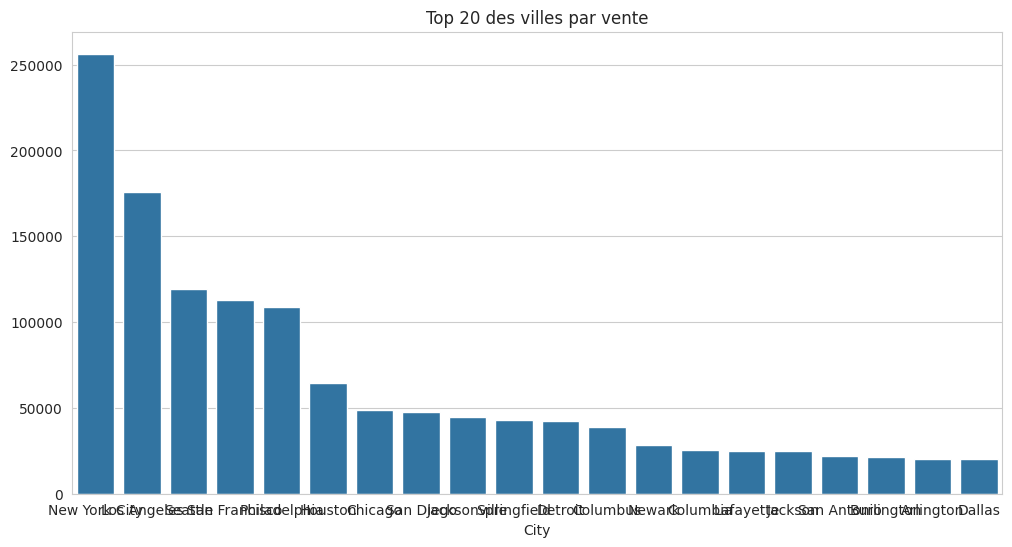

In [32]:
#Top 20 des villes par vente
top_20_cities = (
    df.groupby('City')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)
print(top_20_cities)
#Visualisation
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_20_cities.index,
    y=top_20_cities.values
)

plt.title("Top 20 des villes par vente")
plt.show()

City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1013
Newark            5793.7588
Columbia          5606.1167
Richmond          5567.2486
Providence        5505.6569
Henderson         4911.8609
Arlington         4169.6969
Lakewood          3234.0278
Milwaukee         2793.0851
Name: Profit, dtype: float64


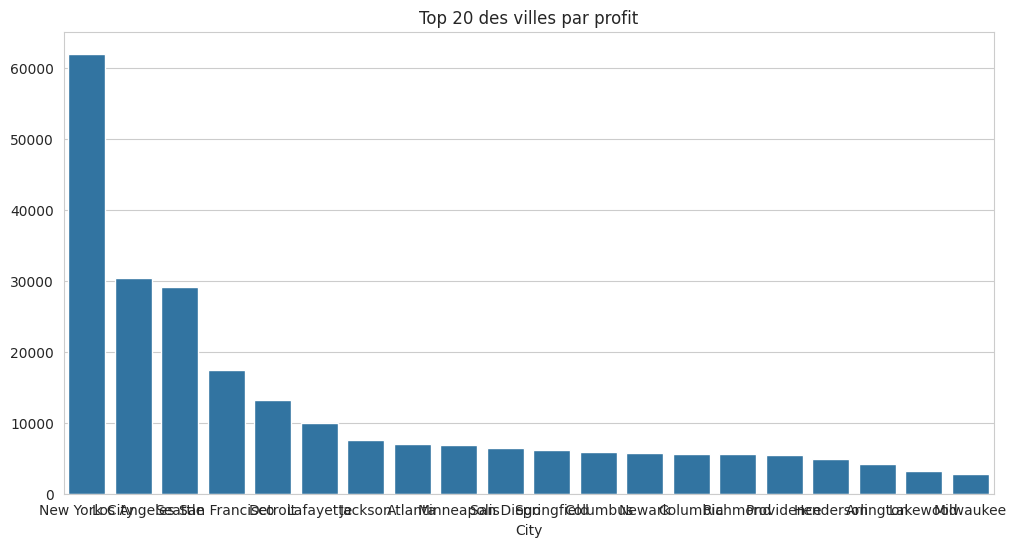

In [33]:
#Top 20 des villes par profit
top_20_cities_profit = (
    df.groupby('City')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)
print(top_20_cities_profit)
#Visualisation
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_20_cities_profit.index,
    y=top_20_cities_profit.values
)

plt.title("Top 20 des villes par profit")
plt.show()

In [39]:
#Analyse des différences de rentabilités entre les 20 principales villes en fonction des ventes et des profits
analisys_cities = (
    df.groupby('City')
    .agg({
        'Sales': 'sum',
        'Profit': 'sum'
        })
)

analisys_cities['profit_margin'] = (
    analisys_cities['Profit'] /
    analisys_cities['Sales']
)
print(analisys_cities.sort_values(by='profit_margin', ascending=False).head(20))


                 Sales    Profit  profit_margin
City                                           
Atlantic City   23.360   11.6800       0.500000
Grand Island    15.960    7.9800       0.500000
New Brunswick   14.770    7.1567       0.484543
Summerville    406.940  196.9132       0.483888
Holland        137.860   66.6588       0.483525
Antioch         19.440    9.3312       0.480000
Davis           32.400   15.5520       0.480000
Royal Oak       35.340   16.9632       0.480000
Lindenhurst     55.480   26.6304       0.480000
Bozeman         43.660   20.8106       0.476651
San Clemente    90.058   42.5419       0.472383
San Mateo       75.180   35.3346       0.470000
Layton           4.960    2.3312       0.470000
Hagerstown      43.800   20.5860       0.470000
Gulfport       166.500   77.5761       0.465923
East Orange    377.270  174.6191       0.462849
Norfolk         17.430    8.0178       0.460000
Rogers          40.410   18.5886       0.460000
Iowa City        9.990    4.4955       0

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64


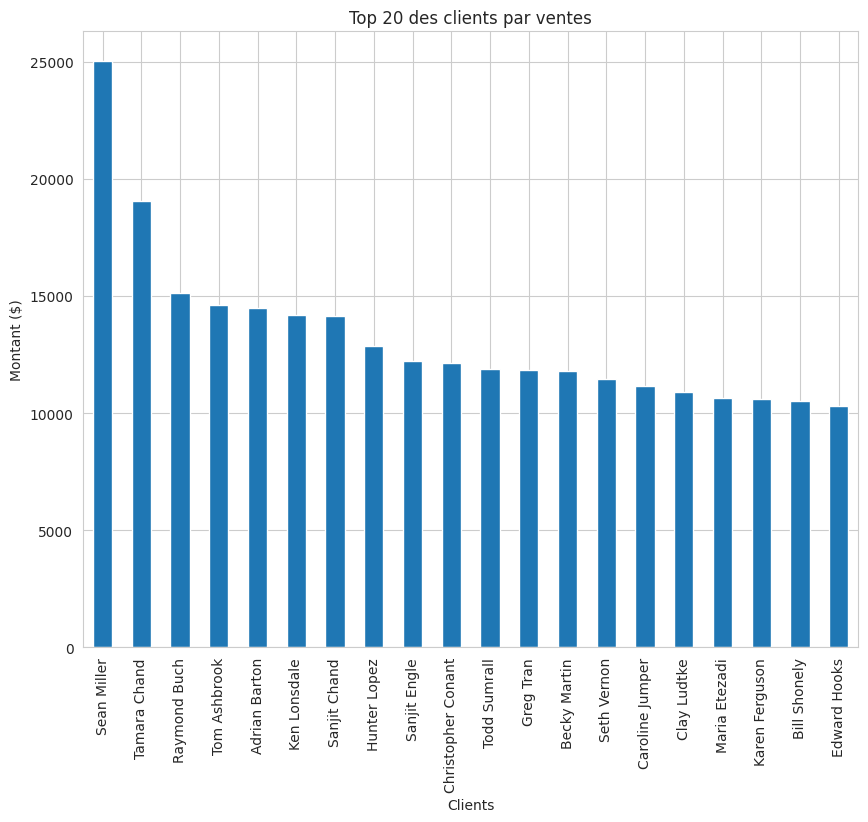

In [47]:
#Top 20 des clients par ventes
top_20_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)
print(top_20_customers)

#Visualisation
top_20_customers.plot(kind='bar', figsize=(10,8))
plt.title('Top 20 des clients par ventes')
plt.ylabel('Montant ($)')
plt.xlabel('Clients')
plt.show()

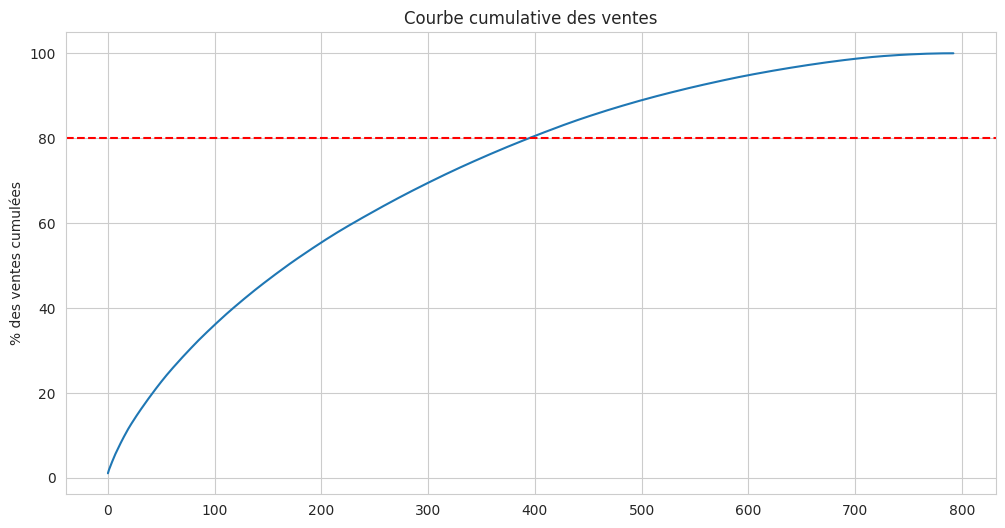

In [48]:
#Courbe cumulative des ventes
customer_sales = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
sales_pareto = customer_sales.reset_index()

sales_pareto["CumSales"] = (
    sales_pareto["Sales"]
    .cumsum()
)

sales_pareto["CumPercent"] = (
    sales_pareto["CumSales"]
    /
    sales_pareto["Sales"].sum()
) * 100
plt.figure(figsize=(12,6))

plt.plot(
    sales_pareto["CumPercent"]
)

plt.axhline(
    y=80,
    color="red",
    linestyle="--"
)

plt.title("Courbe cumulative des ventes")

plt.ylabel("% des ventes cumulées")

plt.show()

In [49]:
#Vérification du principe de Pareto pour les ventes
clients_80 = len(
    sales_pareto[
        sales_pareto["CumPercent"] <= 80
    ]
)

pourcentage_clients = (
    clients_80 /
    len(sales_pareto)
) * 100
print(f"{pourcentage_clients:.2f}% des clients génèrent 80% des ventes.")

49.81% des clients génèrent 80% des ventes.


*États à privilégier:*

Californie
New York
Washington
Texas

Car ils génèrent souvent les plus fortes ventes et profits.

*États à surveiller:*

États présentant un profit négatif malgré des ventes élevées.
Villes prioritaires

Les villes apparaissant simultanément dans :

Top 20 ventes
Top 20 bénéfices

Stratégie Pareto
Si environ 20 % des clients génèrent 80 % des bénéfices :

Programme VIP
Réductions ciblées
Fidélisation renforcée

pour ces clients à forte valeur.